In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['svg.fonttype'] = 'none'

## load layout from file, and plot to check

In [3]:
Experiment1_Layout = pd.read_csv("251020_mChPOLR2A_RSC_PIB/METADATA/251020_mChPOLR2A_PIB_RSC.csv")
Experiment2_Layout = pd.read_csv("251027_mChPOLR2A_RSC_PIB/METADATA/251027_mChPOLR2A_PIB_RSC.csv")

In [4]:
Experiment2_Layout

,WELL,CELL,DRUG,PRIMARY,SECONDARY,SEEDING_DENSITY
0,C03,HCT116,No treatment,No primary,No primary,500
1,C04,HCT116,No treatment,pSer2 Pol II (3E10),Goat anti-rat Alexa488+,500
2,C05,HCT116,No treatment,pSer2 Pol II (3E10),Goat anti-rat Alexa488+,500
3,C06,HCT116,No treatment,pSer2 Pol II (3E10),Goat anti-rat Alexa488+,500
4,C07,HCT116,No treatment,pSer2 Pol II (3E10),Goat anti-rat Alexa488+,500
...,...,...,...,...,...,...
235,N18,HCT116,No treatment,Total Pol II (F12),Goat anti-mouse Alexa488+,750
236,N19,HCT116,No treatment,Total Pol II (F12),Goat anti-mouse Alexa488+,750
237,N20,HCT116,No treatment,Total Pol II (F12),Goat anti-mouse Alexa488+,750
238,N21,HCT116,No treatment,Total Pol II (F12),Goat anti-mouse Alexa488+,750


## load quantification files from relevant directories, and assemble into data frames

In [5]:
quantification_directory_1 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/251020_mChPOLR2A_RSC_PIB/20251024_155958_578/QUANTIFICATION/")
quantification_files_1 = glob.glob(str(quantification_directory_1 / "*.csv"))

quantification_directory_2 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/251027_mChPOLR2A_RSC_PIB/20251103_183938_826/QUANTIFICATION/")
quantification_files_2 = glob.glob(str(quantification_directory_2 / "*.csv"))

len(quantification_files_1), len(quantification_files_2)

(720, 772)

In [6]:
Path(quantification_files_1[10]).stem, Path(quantification_files_1[10]).stem[4:7],Path(quantification_files_1[10]).stem[40:44]

('WellL04_Channel561,405,None,488_Seq0064_0001.ome', 'L04', '0001')

In [7]:
qdfs = list()


for f in tqdm(quantification_files_1):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_1['file'].tolist()


wellnames = [f[4:7] for f in files]
quantifcation_percell_1['well'] = wellnames

fovs = [f[40:44] for f in files]
quantifcation_percell_1['fov'] = fovs

quantifcation_percell_1 = quantifcation_percell_1.query('Nuclei_is_border == False')

quantifcation_percell_1['Nucleus_area_squaremicrons'] = quantifcation_percell_1['Nuclei_area'] * 0.161569 * 0.161569

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 720/720 [00:02<00:00, 289.22it/s]


In [8]:
Experiment1_Intensities = pd.DataFrame({
    "WELL" : quantifcation_percell_1['well'],
    "IF_488_Intensity" : quantifcation_percell_1['Nuclei_intensity_mean_488'],
    "RFP_561_Intensity" : quantifcation_percell_1['Nuclei_intensity_mean_561'],
    "DAPI_Intensity" : quantifcation_percell_1['Nuclei_intensity_mean_405'],
    "DAPI_Intensity_Sum" : quantifcation_percell_1['Nuclei_intensity_sum_405'],
    "NucleusArea" : quantifcation_percell_1['Nuclei_area'],
    "NucleusArea_um2" : quantifcation_percell_1['Nucleus_area_squaremicrons']
})

In [9]:
Experiment1_CountsByWell = Experiment1_Intensities.groupby('WELL').count()['NucleusArea'].reset_index().merge(Experiment1_Layout, how = 'left')
Experiment1_CountsByWell.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
Experiment1_IntensitiesByCell = Experiment1_Intensities.merge(Experiment1_Layout, how = 'left')
Experiment1_IntensitiesByWell = Experiment1_Intensities.groupby('WELL').mean().reset_index().merge(Experiment1_Layout, how = 'left')
Experiment1_IntensitiesByWell = Experiment1_IntensitiesByWell.merge(Experiment1_CountsByWell, how = 'left')

In [10]:
qdfs = list()


for f in tqdm(quantification_files_2):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_2 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_2['file'].tolist()


wellnames = [f[4:7] for f in files]
quantifcation_percell_2['well'] = wellnames

fovs = [f[40:44] for f in files]
quantifcation_percell_2['fov'] = fovs

quantifcation_percell_2 = quantifcation_percell_2.query('Nuclei_is_border == False')

quantifcation_percell_2['Nucleus_area_squaremicrons'] = quantifcation_percell_2['Nuclei_area'] * 0.161569 * 0.161569

Experiment2_Intensities = pd.DataFrame({
    "WELL" : quantifcation_percell_2['well'],
    "IF_488_Intensity" : quantifcation_percell_2['Nuclei_intensity_mean_488'],
    "RFP_561_Intensity" : quantifcation_percell_2['Nuclei_intensity_mean_561'],
    "DAPI_Intensity" : quantifcation_percell_2['Nuclei_intensity_mean_405'],
    "DAPI_Intensity_Sum" : quantifcation_percell_2['Nuclei_intensity_sum_405'],
    "NucleusArea" : quantifcation_percell_2['Nuclei_area'],
    "NucleusArea_um2" : quantifcation_percell_2['Nucleus_area_squaremicrons']
})

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 772/772 [00:02<00:00, 307.15it/s]


In [11]:
Experiment2_CountsByWell = Experiment2_Intensities.groupby('WELL').count()['NucleusArea'].reset_index().merge(Experiment2_Layout, how = 'left')
Experiment2_CountsByWell.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
Experiment2_IntensitiesByCell = Experiment2_Intensities.merge(Experiment2_Layout, how = 'left')
Experiment2_IntensitiesByWell = Experiment2_Intensities.groupby('WELL').mean().reset_index().merge(Experiment2_Layout, how = 'left')
Experiment2_IntensitiesByWell = Experiment2_IntensitiesByWell.merge(Experiment2_CountsByWell, how = 'left')

## normalise RFP and IF within experiments and combine

In [12]:
Experiment1_IntensitiesByCell['RFP_561_Intensity_BGS'] = Experiment1_IntensitiesByCell['RFP_561_Intensity'] - Experiment1_IntensitiesByCell.query('CELL == "HCT116"')['RFP_561_Intensity'].mean()
Experiment1_IntensitiesByCell['IF_488_Intensity_BGS_Mouse'] = Experiment1_IntensitiesByCell['IF_488_Intensity'] - Experiment1_IntensitiesByCell.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-mouse Alexa488+"').IF_488_Intensity.mean()
Experiment1_IntensitiesByCell['IF_488_Intensity_BGS_Rat'] = Experiment1_IntensitiesByCell['IF_488_Intensity'] - Experiment1_IntensitiesByCell.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-rat Alexa488+"').IF_488_Intensity.mean()

Experiment2_IntensitiesByCell['RFP_561_Intensity_BGS'] = Experiment2_IntensitiesByCell['RFP_561_Intensity'] - Experiment2_IntensitiesByCell.query('CELL == "HCT116"')['RFP_561_Intensity'].mean()
Experiment2_IntensitiesByCell['IF_488_Intensity_BGS_Mouse'] = Experiment2_IntensitiesByCell['IF_488_Intensity'] - Experiment2_IntensitiesByCell.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-mouse Alexa488+"').IF_488_Intensity.mean()
Experiment2_IntensitiesByCell['IF_488_Intensity_BGS_Rat'] = Experiment2_IntensitiesByCell['IF_488_Intensity'] - Experiment2_IntensitiesByCell.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-rat Alexa488+"').IF_488_Intensity.mean()

In [13]:
Experiment1_IntensitiesByCell['RFP_561_Intensity_Sum'] =  Experiment1_IntensitiesByCell['RFP_561_Intensity_BGS'] * Experiment1_IntensitiesByCell['NucleusArea_um2']
Experiment1_IntensitiesByCell['IF_488_Intensity_Mouse_Sum'] = Experiment1_IntensitiesByCell['IF_488_Intensity_BGS_Mouse'] * Experiment1_IntensitiesByCell['NucleusArea_um2']
Experiment1_IntensitiesByCell['IF_488_Intensity_Rat_Sum'] = Experiment1_IntensitiesByCell['IF_488_Intensity_BGS_Rat'] * Experiment1_IntensitiesByCell['NucleusArea_um2']

Experiment2_IntensitiesByCell['RFP_561_Intensity_Sum'] =  Experiment2_IntensitiesByCell['RFP_561_Intensity_BGS'] * Experiment2_IntensitiesByCell['NucleusArea_um2']
Experiment2_IntensitiesByCell['IF_488_Intensity_Mouse_Sum'] = Experiment2_IntensitiesByCell['IF_488_Intensity_BGS_Mouse'] * Experiment2_IntensitiesByCell['NucleusArea_um2']
Experiment2_IntensitiesByCell['IF_488_Intensity_Rat_Sum'] = Experiment2_IntensitiesByCell['IF_488_Intensity_BGS_Rat'] * Experiment2_IntensitiesByCell['NucleusArea_um2']


In [14]:
Experiment1_IntensitiesByCell['RFP_561_Intensity_FC'] = Experiment1_IntensitiesByCell['RFP_561_Intensity_BGS'] / Experiment1_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Vehicle"')['RFP_561_Intensity_BGS'].mean()
Experiment1_IntensitiesByCell['IF_488_Intensity_F12_FC'] = Experiment1_IntensitiesByCell['IF_488_Intensity_BGS_Mouse'] / Experiment1_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Vehicle" & PRIMARY == "Total Pol II (F12)"')['IF_488_Intensity_BGS_Mouse'].mean()
Experiment1_IntensitiesByCell['IF_488_Intensity_3E10_FC'] = Experiment1_IntensitiesByCell['IF_488_Intensity_BGS_Rat'] / Experiment1_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Vehicle" & PRIMARY == "pSer2 Pol II (3E10)"')['IF_488_Intensity_BGS_Rat'].mean()

Experiment2_IntensitiesByCell['RFP_561_Intensity_FC'] = Experiment2_IntensitiesByCell['RFP_561_Intensity_BGS'] / Experiment2_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Vehicle"')['RFP_561_Intensity_BGS'].mean()
Experiment2_IntensitiesByCell['IF_488_Intensity_F12_FC'] = Experiment2_IntensitiesByCell['IF_488_Intensity_BGS_Mouse'] / Experiment2_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Vehicle" & PRIMARY == "Total Pol II (F12)"')['IF_488_Intensity_BGS_Mouse'].mean()
Experiment2_IntensitiesByCell['IF_488_Intensity_3E10_FC'] = Experiment2_IntensitiesByCell['IF_488_Intensity_BGS_Rat'] / Experiment2_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Vehicle" & PRIMARY == "pSer2 Pol II (3E10)"')['IF_488_Intensity_BGS_Rat'].mean()



In [15]:
Experiment1_IntensitiesByCell['RFP_561_Intensity_FC_Sum'] =  Experiment1_IntensitiesByCell['RFP_561_Intensity_FC'] * Experiment1_IntensitiesByCell['NucleusArea_um2']
Experiment1_IntensitiesByCell['IF_488_Intensity_F12_FC_Sum'] = Experiment1_IntensitiesByCell['IF_488_Intensity_F12_FC'] * Experiment1_IntensitiesByCell['NucleusArea_um2']
Experiment1_IntensitiesByCell['IF_488_Intensity_3E10_FC_Sum'] = Experiment1_IntensitiesByCell['IF_488_Intensity_3E10_FC'] * Experiment1_IntensitiesByCell['NucleusArea_um2']

Experiment2_IntensitiesByCell['RFP_561_Intensity_FC_Sum'] =  Experiment2_IntensitiesByCell['RFP_561_Intensity_FC'] * Experiment2_IntensitiesByCell['NucleusArea_um2']
Experiment2_IntensitiesByCell['IF_488_Intensity_F12_FC_Sum'] = Experiment2_IntensitiesByCell['IF_488_Intensity_F12_FC'] * Experiment2_IntensitiesByCell['NucleusArea_um2']
Experiment2_IntensitiesByCell['IF_488_Intensity_3E10_FC_Sum'] = Experiment2_IntensitiesByCell['IF_488_Intensity_3E10_FC'] * Experiment2_IntensitiesByCell['NucleusArea_um2']

In [16]:
# filter very small cells

Experiment1_IntensitiesByCell = Experiment1_IntensitiesByCell.query('NucleusArea > 2000')
Experiment2_IntensitiesByCell = Experiment2_IntensitiesByCell.query('NucleusArea > 2000')

## define area bins and check for both experiments

In [17]:
area_bins_veh = range(80,320,40)
area_bins_veh_centre = []
for i,b in enumerate(area_bins_veh[:-1]):
    g = (area_bins_veh[i+1] - b)
    h = b + g/2
    area_bins_veh_centre.append(h)

area_bins_pib = range(120,400,40)
area_bins_pib_centre = []
for i,b in enumerate(area_bins_pib[:-1]):
    g = (area_bins_pib[i+1] - b)
    h = b + g/2
    area_bins_pib_centre.append(h)

In [18]:
area_bins_veh_centre, area_bins_pib_centre

([100.0, 140.0, 180.0, 220.0, 260.0],
 [140.0, 180.0, 220.0, 260.0, 300.0, 340.0])

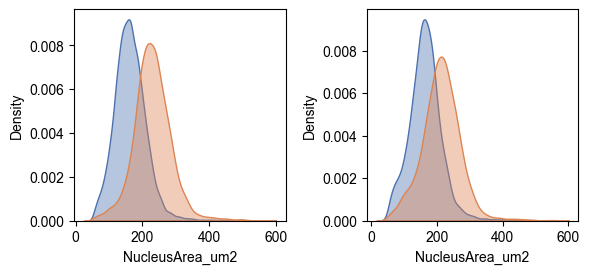

In [19]:
f, a = plt.subplots(ncols = 2, figsize = (6,3))

sns.kdeplot(Experiment1_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Vehicle"').NucleusArea_um2,
            ax = a[0],
            color = sns.color_palette('deep')[0],
            fill = True,
            alpha = 0.4,
            clip = (0,600),
            common_norm = False)

sns.kdeplot(Experiment1_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Palbociclib 1 µM"').NucleusArea_um2,
            ax = a[0],
            color = sns.color_palette('deep')[1],
            fill = True,
            alpha = 0.4,
            clip = (0,600),
            common_norm = False)

sns.kdeplot(Experiment2_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Vehicle"').NucleusArea_um2,
            ax = a[1],
            color = sns.color_palette('deep')[0],
            fill = True,
            alpha = 0.4,
            clip = (0,600),
            common_norm = False)

sns.kdeplot(Experiment2_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Palbociclib 1 µM"').NucleusArea_um2,
            ax = a[1],
            color = sns.color_palette('deep')[1],
            fill = True,
            alpha = 0.4,
            clip = (0,600),
            common_norm = False)

a[0].set_box_aspect(1)
a[1].set_box_aspect(1)

plt.tight_layout()

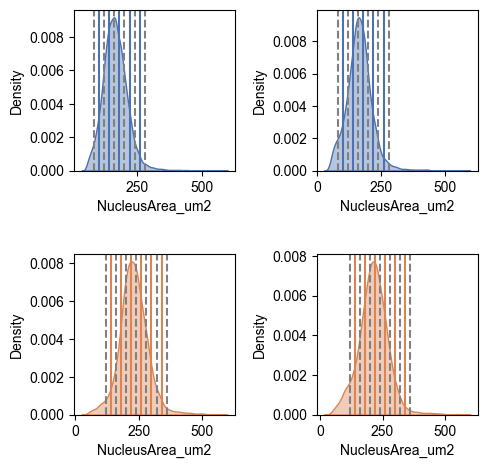

In [20]:
f, a = plt.subplots(ncols = 2, nrows = 2, figsize = (5,5))

sns.kdeplot(Experiment1_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Vehicle"').NucleusArea_um2,
            ax = a[0,0],
            color = sns.color_palette('deep')[0],
            fill = True,
            alpha = 0.4,
            clip = (0,600),
            common_norm = False)

sns.kdeplot(Experiment1_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Palbociclib 1 µM"').NucleusArea_um2,
            ax = a[1,0],
            color = sns.color_palette('deep')[1],
            fill = True,
            alpha = 0.4,
            clip = (0,600),
            common_norm = False)

sns.kdeplot(Experiment2_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Vehicle"').NucleusArea_um2,
            ax = a[0,1],
            color = sns.color_palette('deep')[0],
            fill = True,
            alpha = 0.4,
            clip = (0,600),
            common_norm = False)

sns.kdeplot(Experiment2_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Palbociclib 1 µM"').NucleusArea_um2,
            ax = a[1,1],
            color = sns.color_palette('deep')[1],
            fill = True,
            alpha = 0.4,
            clip = (0,600),
            common_norm = False)

for c in area_bins_veh_centre:
    a[0,0].axvline(c, color = sns.color_palette('deep')[0])
    a[0,1].axvline(c, color = sns.color_palette('deep')[0])

for d in area_bins_veh:
    a[0,0].axvline(d, color = 'grey', linestyle = '--')
    a[0,1].axvline(d, color = 'grey', linestyle = '--')
    
for c in area_bins_pib_centre:
    a[1,0].axvline(c, color = sns.color_palette('deep')[1])
    a[1,1].axvline(c, color = sns.color_palette('deep')[1])

for d in area_bins_pib:
    a[1,0].axvline(d, color = 'grey', linestyle = '--')
    a[1,1].axvline(d, color = 'grey', linestyle = '--')


for i in range(2):
    for j in range(2):
        a[j,i].set_box_aspect(1)

plt.tight_layout()

In [21]:
## compare volume to sum of mCherry intensity per cell

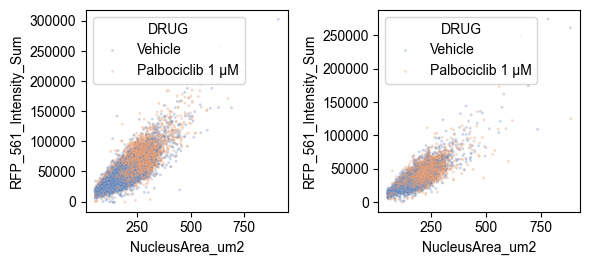

In [22]:
f, a = plt.subplots(ncols = 2, figsize = (6,3))

sns.scatterplot(Experiment1_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG in ["Vehicle", "Palbociclib 1 µM"]'),
                x = 'NucleusArea_um2',
                y = 'RFP_561_Intensity_Sum',
                hue = 'DRUG', hue_order = ["Vehicle", "Palbociclib 1 µM"], palette = 'deep',
                ax = a[0],
                s = 4,
                alpha = 0.3)

sns.scatterplot(Experiment2_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG in ["Vehicle", "Palbociclib 1 µM"]'),
                x = 'NucleusArea_um2',
                y = 'RFP_561_Intensity_Sum',
                hue = 'DRUG', hue_order = ["Vehicle", "Palbociclib 1 µM"], palette = 'deep',
                ax = a[1],
                s = 4,
                alpha = 0.3)

for i in [0,1]:
    a[i].set_box_aspect(1)
    #a[i].set_xlim(0,20000)
    #a[i].set_ylim(0,12000000)

plt.tight_layout()

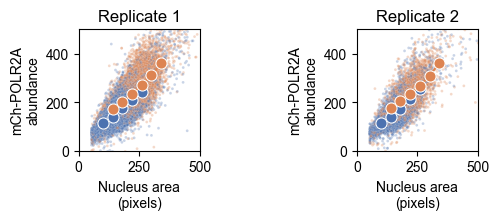

In [23]:
f, a = plt.subplots(ncols = 2, figsize = (6,2))

h = sns.scatterplot(Experiment1_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG in ["Vehicle", "Palbociclib 1 µM"]'),
                x = 'NucleusArea_um2',
                y = 'RFP_561_Intensity_FC_Sum',
                hue = 'DRUG', hue_order = ["Vehicle", "Palbociclib 1 µM"], palette = 'deep',
                ax = a[0],
                s = 4,
                alpha = 0.3,
             legend = False)


h = sns.scatterplot(Experiment2_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG in ["Vehicle", "Palbociclib 1 µM"]'),
                x = 'NucleusArea_um2',
                y = 'RFP_561_Intensity_FC_Sum',
                hue = 'DRUG', hue_order = ["Vehicle", "Palbociclib 1 µM"], palette = 'deep',
                ax = a[1],
                s = 4,
                alpha = 0.3,
             legend = False)


Experiment1_mCh_Veh = Experiment1_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Vehicle"')
Experiment1_mCh_Veh_Mean = Experiment1_mCh_Veh[['NucleusArea', 'RFP_561_Intensity_FC_Sum']].groupby(pd.cut(Experiment1_mCh_Veh.NucleusArea_um2, area_bins_veh)).mean()

Experiment1_mCh_PIB = Experiment1_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Palbociclib 1 µM"')
Experiment1_mCh_PIB_Mean = Experiment1_mCh_PIB[['NucleusArea', 'RFP_561_Intensity_FC_Sum']].groupby(pd.cut(Experiment1_mCh_PIB.NucleusArea_um2, area_bins_pib)).mean()

sns.lineplot(x = area_bins_veh_centre,
             y = Experiment1_mCh_Veh_Mean['RFP_561_Intensity_FC_Sum'],
             marker = 'o', markersize = 8,
             color = sns.color_palette('deep')[0],
             ax = a[0])
             
sns.lineplot(x = area_bins_pib_centre,
             y = Experiment1_mCh_PIB_Mean['RFP_561_Intensity_FC_Sum'],
             marker = 'o', markersize = 8,
             color = sns.color_palette('deep')[1],
             ax = a[0])

Experiment2_mCh_Veh = Experiment2_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Vehicle"')
Experiment2_mCh_Veh_Mean = Experiment2_mCh_Veh[['NucleusArea', 'RFP_561_Intensity_FC_Sum']].groupby(pd.cut(Experiment2_mCh_Veh.NucleusArea_um2, area_bins_veh)).mean()

Experiment2_mCh_PIB = Experiment2_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Palbociclib 1 µM"')
Experiment2_mCh_PIB_Mean = Experiment2_mCh_PIB[['NucleusArea', 'RFP_561_Intensity_FC_Sum']].groupby(pd.cut(Experiment2_mCh_PIB.NucleusArea_um2, area_bins_pib)).mean()

sns.lineplot(x = area_bins_veh_centre,
             y = Experiment2_mCh_Veh_Mean['RFP_561_Intensity_FC_Sum'],
             marker = 'o', markersize = 8,
             color = sns.color_palette('deep')[0],
             ax = a[1])
             
sns.lineplot(x = area_bins_pib_centre,
             y = Experiment2_mCh_PIB_Mean['RFP_561_Intensity_FC_Sum'],
             marker = 'o', markersize = 8,
             color = sns.color_palette('deep')[1],
             ax = a[1])


for i in [0,1]:
    a[i].set_box_aspect(1)
    a[i].set_xlim(0,500)
    a[i].set_ylim(0,500)

plt.tight_layout()

a[0].set_title('Replicate 1')
a[1].set_title('Replicate 2')

a[0].set_xlabel('Nucleus area\n(pixels)')
a[1].set_xlabel('Nucleus area\n(pixels)')
a[0].set_ylabel('mCh-POLR2A\nabundance')
a[1].set_ylabel('mCh-POLR2A\nabundance')

## join experiments and plot single cells in sample of complete dataset

In [24]:
Experiment1_IntensitiesByCell['EXPERIMENT'] = '251020'
Experiment2_IntensitiesByCell['EXPERIMENT'] = '251027'

In [25]:
IntensitiesByCell = pd.concat([Experiment1_IntensitiesByCell, Experiment2_IntensitiesByCell])

In [60]:
IntensitiesByCell.columns.tolist()

['WELL',
 'IF_488_Intensity',
 'RFP_561_Intensity',
 'DAPI_Intensity',
 'DAPI_Intensity_Sum',
 'NucleusArea',
 'NucleusArea_um2',
 'CELL',
 'DRUG',
 'CELL_LABEL',
 'PRIMARY',
 'SECONDARY',
 'RFP_561_Intensity_BGS',
 'IF_488_Intensity_BGS_Mouse',
 'IF_488_Intensity_BGS_Rat',
 'RFP_561_Intensity_Sum',
 'IF_488_Intensity_Mouse_Sum',
 'IF_488_Intensity_Rat_Sum',
 'RFP_561_Intensity_FC',
 'IF_488_Intensity_F12_FC',
 'IF_488_Intensity_3E10_FC',
 'RFP_561_Intensity_FC_Sum',
 'IF_488_Intensity_F12_FC_Sum',
 'IF_488_Intensity_3E10_FC_Sum',
 'EXPERIMENT',
 'SEEDING_DENSITY',
 'WELL_UNIQUE']

In [63]:
IntensitiesByCellToSave = IntensitiesByCell[['EXPERIMENT','WELL','CELL', 'DRUG', 'PRIMARY', 'SECONDARY',
                                             'IF_488_Intensity','RFP_561_Intensity', 'DAPI_Intensity', 'NucleusArea', 'NucleusArea_um2', 'RFP_561_Intensity_BGS',
                                             'IF_488_Intensity_BGS_Mouse',
                                             'IF_488_Intensity_BGS_Rat',
                                             'RFP_561_Intensity_Sum',
                                             'IF_488_Intensity_Mouse_Sum',
                                             'IF_488_Intensity_Rat_Sum',
                                             'RFP_561_Intensity_FC', 
                                             'IF_488_Intensity_F12_FC',
                                             'IF_488_Intensity_3E10_FC',
                                             'RFP_561_Intensity_FC_Sum',
                                             'IF_488_Intensity_F12_FC_Sum',
                                             'IF_488_Intensity_3E10_FC_Sum']]

In [64]:
IntensitiesByCellToSave.to_csv("mChPOLR2A_RSC_PIB_per_cell_data.csv")

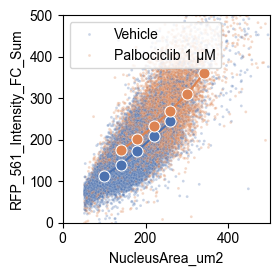

In [26]:
f, a = plt.subplots(figsize = (3,3))

sns.scatterplot(IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG in ["Vehicle", "Palbociclib 1 µM"]'),
                x = 'NucleusArea_um2',
                y = 'RFP_561_Intensity_FC_Sum',
                hue = 'DRUG', hue_order = ["Vehicle", "Palbociclib 1 µM"], palette = 'deep',
                ax = a,
                s = 4,
                alpha = 0.3)

mCh_Veh = IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Vehicle"')
mCh_Veh_Mean = mCh_Veh[['NucleusArea', 'RFP_561_Intensity_FC_Sum']].groupby(pd.cut(mCh_Veh.NucleusArea_um2, area_bins_veh)).mean()

mCh_PIB = IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Palbociclib 1 µM"')
mCh_PIB_Mean = mCh_PIB[['NucleusArea', 'RFP_561_Intensity_FC_Sum']].groupby(pd.cut(mCh_PIB.NucleusArea_um2, area_bins_pib)).mean()

sns.lineplot(x = area_bins_veh_centre,
             y = mCh_Veh_Mean['RFP_561_Intensity_FC_Sum'],
             marker = 'o', markersize = 8,
             color = sns.color_palette('deep')[0],
             ax = a)
             
sns.lineplot(x = area_bins_pib_centre,
             y = mCh_PIB_Mean['RFP_561_Intensity_FC_Sum'],
             marker = 'o', markersize = 8,
             color = sns.color_palette('deep')[1],
             ax = a)

a.set_box_aspect(1)
a.set_xlim(0,500)
a.set_ylim(0,500)

plt.tight_layout()

In [27]:
IntensitiesByCell.NucleusArea_um2.median()

161.06502266536998

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


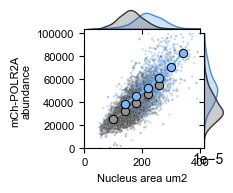

In [28]:
g = sns.jointplot(IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG in ["Vehicle", "Palbociclib 1 µM"]').sample(frac = 0.1),
              x = 'NucleusArea_um2',
              y = 'RFP_561_Intensity_Sum',
              hue = 'DRUG', hue_order = ["Vehicle", "Palbociclib 1 µM"], palette = sns.color_palette(['xkcd:dark grey', 'xkcd:dark sky blue']),
              height = 1.8,
              s = 3,
              alpha = 0.3,
              xlim = (0,400),
              ylim = (0,100000),
              joint_kws = {'alpha' : 0.2},
              marginal_kws=dict(common_norm = False),
                  legend = False)

mCh_Veh = IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Vehicle"')
mCh_Veh_Mean = mCh_Veh[['NucleusArea_um2', 'RFP_561_Intensity_Sum']].groupby(pd.cut(mCh_Veh.NucleusArea_um2, area_bins_veh)).mean()

mCh_PIB = IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Palbociclib 1 µM"')
mCh_PIB_Mean = mCh_PIB[['NucleusArea_um2', 'RFP_561_Intensity_Sum']].groupby(pd.cut(mCh_PIB.NucleusArea_um2, area_bins_pib)).mean()

sns.lineplot(x = area_bins_veh_centre,
             y = mCh_Veh_Mean['RFP_561_Intensity_Sum'],
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             color = 'xkcd:grey')
             
sns.lineplot(x = area_bins_pib_centre,
             y = mCh_PIB_Mean['RFP_561_Intensity_Sum'],
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             color = 'xkcd:sky blue')

plt.xlabel('Nucleus area um2', fontsize = 8)
plt.ylabel('mCh-POLR2A\nabundance', fontsize = 8)
plt.tick_params(axis = 'both', labelsize = 8)

plt.savefig('Area_vs_mChPOLR2A_abundance_VehPIB_2reps.svg')

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


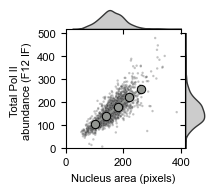

In [29]:
sns.jointplot(IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Vehicle" & PRIMARY == "Total Pol II (F12)"').sample(frac = 0.1),
              x = 'NucleusArea_um2',
              y = 'IF_488_Intensity_F12_FC_Sum',
              hue = 'DRUG', palette = sns.color_palette(['xkcd:dark grey']),
              height = 1.8,
              s = 3,
              alpha = 0.3,
              xlim = (0,400),
              ylim = (0,500),
              legend = False,
              joint_kws = {'alpha' : 0.2},
              marginal_kws=dict(common_norm = False))


mCh_Veh = IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Vehicle" & PRIMARY == "Total Pol II (F12)"')
mCh_Veh_Mean = mCh_Veh[['NucleusArea', 'IF_488_Intensity_F12_FC_Sum']].groupby(pd.cut(mCh_Veh.NucleusArea_um2, area_bins_veh)).mean()

sns.lineplot(x = area_bins_veh_centre,
             y = mCh_Veh_Mean['IF_488_Intensity_F12_FC_Sum'],
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             color = 'xkcd:grey')

plt.xlabel('Nucleus area (pixels)', fontsize = 8)
plt.ylabel('Total Pol II\nabundance (F12 IF)', fontsize = 8)
plt.tick_params(axis = 'both', labelsize = 8)

plt.savefig('Area_vs_F12_abundance_Veh_2reps.svg')

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


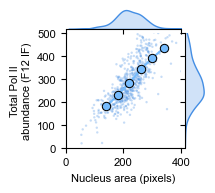

In [30]:
sns.jointplot(IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Palbociclib 1 µM" & PRIMARY == "Total Pol II (F12)"').sample(frac = 0.1),
              x = 'NucleusArea_um2',
              y = 'IF_488_Intensity_F12_FC_Sum',
              hue = 'DRUG', palette = sns.color_palette(['xkcd:dark sky blue']),
              height = 1.8,
              s = 3,
              alpha = 0.3,
              xlim = (0,400),
              ylim = (0,500),
              legend = False,
              joint_kws = {'alpha' : 0.2},
              marginal_kws=dict(common_norm = False))

mCh_PIB = IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Palbociclib 1 µM" & PRIMARY == "Total Pol II (F12)"')
mCh_PIB_Mean = mCh_PIB[['NucleusArea_um2', 'IF_488_Intensity_F12_FC_Sum']].groupby(pd.cut(mCh_PIB.NucleusArea_um2, area_bins_pib)).mean()
             
sns.lineplot(x = area_bins_pib_centre,
             y = mCh_PIB_Mean['IF_488_Intensity_F12_FC_Sum'],
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             color = 'xkcd:sky blue')



plt.xlabel('Nucleus area (pixels)', fontsize = 8)
plt.ylabel('Total Pol II\nabundance (F12 IF)', fontsize = 8)
plt.tick_params(axis = 'both', labelsize = 8)

plt.savefig('Area_vs_F12_abundance_PIB_2reps.svg')

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


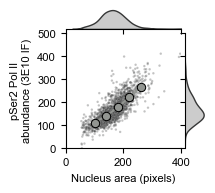

In [31]:
sns.jointplot(IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Vehicle" & PRIMARY == "pSer2 Pol II (3E10)"').sample(frac = 0.1),
              x = 'NucleusArea_um2',
              y = 'IF_488_Intensity_3E10_FC_Sum',
              hue = 'DRUG', palette = sns.color_palette(['xkcd:dark grey']),
              height = 1.8,
              s = 3,
              alpha = 0.3,
              xlim = (0,400),
              ylim = (0,500),
              legend = False,
              joint_kws = {'alpha' : 0.2},
              marginal_kws=dict(common_norm = False))

mCh_Veh = IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Vehicle" & PRIMARY == "pSer2 Pol II (3E10)"')
mCh_Veh_Mean = mCh_Veh[['NucleusArea', 'IF_488_Intensity_3E10_FC_Sum']].groupby(pd.cut(mCh_Veh.NucleusArea_um2, area_bins_veh)).mean()

sns.lineplot(x = area_bins_veh_centre,
             y = mCh_Veh_Mean['IF_488_Intensity_3E10_FC_Sum'],
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             color = 'xkcd:grey')

plt.xlabel('Nucleus area (pixels)', fontsize = 8)
plt.ylabel('pSer2 Pol II\nabundance (3E10 IF)', fontsize = 8)
plt.tick_params(axis = 'both', labelsize = 8)

plt.savefig('Area_vs_3E10_abundance_Veh_2reps.svg')

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


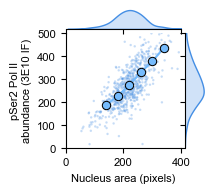

In [32]:
sns.jointplot(IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Palbociclib 1 µM" & PRIMARY == "pSer2 Pol II (3E10)"').sample(frac = 0.1),
              x = 'NucleusArea_um2',
              y = 'IF_488_Intensity_3E10_FC_Sum',
              hue = 'DRUG', palette = sns.color_palette(['xkcd:dark sky blue']),
              height = 1.8,
              s = 3,
              alpha = 0.3,
              xlim = (0,400),
              ylim = (0,500),
              legend = False,
              joint_kws = {'alpha' : 0.2},
              marginal_kws=dict(common_norm = False))

mCh_PIB = IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Palbociclib 1 µM" & PRIMARY == "pSer2 Pol II (3E10)"')
mCh_PIB_Mean = mCh_PIB[['NucleusArea_um2', 'IF_488_Intensity_3E10_FC_Sum']].groupby(pd.cut(mCh_PIB.NucleusArea_um2, area_bins_pib)).mean()
             
sns.lineplot(x = area_bins_pib_centre,
             y = mCh_PIB_Mean['IF_488_Intensity_3E10_FC_Sum'],
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             color = 'xkcd:sky blue')

plt.xlabel('Nucleus area (pixels)', fontsize = 8)
plt.ylabel('pSer2 Pol II\nabundance (3E10 IF)', fontsize = 8)
plt.tick_params(axis = 'both', labelsize = 8)

plt.savefig('Area_vs_3E10_abundance_PIB_2reps.svg')

## examine variation of total Pol II immunofluorescence or mCherry-POLR2A fluorescence

<Axes: xlabel='RFP_561_Intensity_FC', ylabel='Count'>

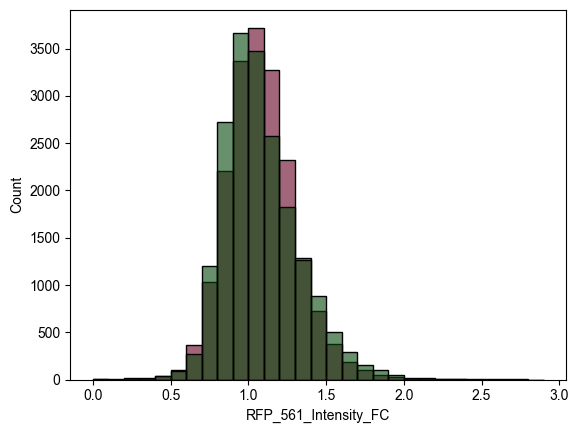

In [33]:
sns.histplot(Experiment1_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG in ["Vehicle", "Palbociclib 1 µM"] & PRIMARY == "Total Pol II (F12)"'),
             x = 'RFP_561_Intensity_FC',
             color = 'xkcd:maroon', alpha = 0.6,
             bins = [b/100 for b in range(0,300,10)])

sns.histplot(Experiment1_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG in ["Vehicle", "Palbociclib 1 µM"] & PRIMARY == "Total Pol II (F12)"'),
             x = 'IF_488_Intensity_F12_FC',
             color = 'xkcd:forest green', alpha = 0.6,
             bins = [b/100 for b in range(0,300,10)])

<Axes: xlabel='RFP_561_Intensity_FC', ylabel='Count'>

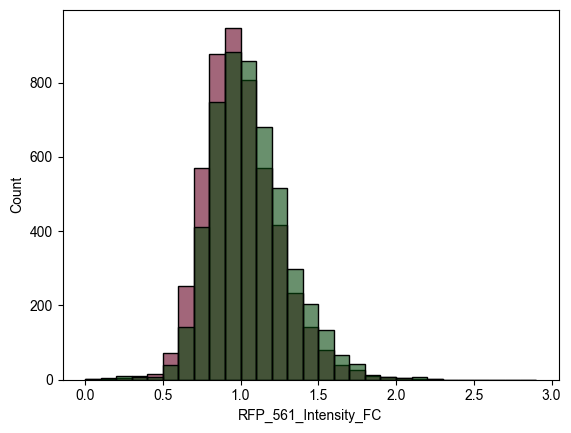

In [34]:
sns.histplot(Experiment2_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG in ["Vehicle", "Palbociclib 1 µM"] & PRIMARY == "Total Pol II (F12)"'),
             x = 'RFP_561_Intensity_FC',
             color = 'xkcd:maroon', alpha = 0.6,
             bins = [b/100 for b in range(0,300,10)])

sns.histplot(Experiment2_IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG in ["Vehicle", "Palbociclib 1 µM"] & PRIMARY == "Total Pol II (F12)"'),
             x = 'IF_488_Intensity_F12_FC',
             color = 'xkcd:forest green', alpha = 0.6,
             bins = [b/100 for b in range(0,300,10)])

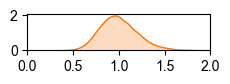

In [35]:
f, a = plt.subplots(figsize = (2.4,1.8))

sns.kdeplot(IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Vehicle"'),
            x = 'RFP_561_Intensity_FC',
            color = 'xkcd:orange',
            fill = True,
            clip = (0,2),
            ax = a)

a.set_box_aspect(0.2)
a.set_xlim(0,2)
a.set_ylabel('')
a.set_xlabel('')

plt.tight_layout()

plt.savefig('mch_polr2a_total_polII_vehicle.svg')

In [36]:
IntensitiesByCell['WELL_UNIQUE'] = IntensitiesByCell['EXPERIMENT'] + '_' + IntensitiesByCell['WELL']

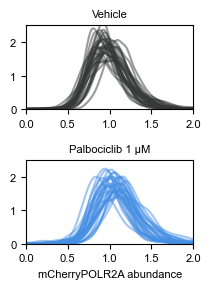

In [37]:
f, a = plt.subplots(figsize = (5,3), nrows  = 2)

plot_dist_mch_veh = IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Vehicle"')

for i in plot_dist_mch_veh['WELL_UNIQUE'].unique():
    sns.kdeplot(plot_dist_mch_veh.query('WELL_UNIQUE == @i'),
                color = 'xkcd:dark grey', alpha = 0.5,
                x = 'RFP_561_Intensity_FC',
                fill = False,
                clip = (0,2),
                ax = a[0])

a[0].set_box_aspect(0.5)
a[0].set_xlim(0,2)
a[0].set_ylim(0,2.5)
a[0].set_ylabel('')
a[0].set_xlabel('')
a[0].set_title('Vehicle', fontsize = 8)
a[0].tick_params(axis = 'both', labelsize = 8)

plot_dist_mch_pib = IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG == "Palbociclib 1 µM"')

for i in plot_dist_mch_pib['WELL_UNIQUE'].unique():
    sns.kdeplot(plot_dist_mch_pib.query('WELL_UNIQUE == @i'),
                color = 'xkcd:dark sky blue', alpha = 0.5,
                x = 'RFP_561_Intensity_FC',
                fill = False,
                clip = (0,2),
                ax = a[1])

a[1].set_box_aspect(0.5)
a[1].set_xlim(0,2)
a[1].set_ylim(0,2.5)
a[1].set_ylabel('')
a[1].set_xlabel('mCherryPOLR2A abundance', fontsize = 8)
a[1].set_title('Palbociclib 1 µM', fontsize = 8)
a[1].tick_params(axis = 'both', labelsize = 8)

plt.tight_layout()

plt.savefig('mch_polr2a_total_polII_vehicle.svg')

## check coefficient of variation of total Pol II across wells

In [38]:
IntensitiesByCell.CELL.unique()

array(['HCT116', 'HCT116 mCherryPOLR2A Clone 2'], dtype=object)

In [39]:
IntensitiesByCell.DRUG.unique()

array(['No treatment', 'Palbociclib 1 µM', 'Roscovitine 10 µM', 'Vehicle'],
      dtype=object)

In [40]:
PolII_Variation = IntensitiesByCell.query('CELL == "HCT116 mCherryPOLR2A Clone 2" & DRUG in ["Vehicle", "No treatment"]')

In [41]:
100 * PolII_Variation.RFP_561_Intensity_FC.std() / PolII_Variation.RFP_561_Intensity_FC.mean()

23.53134755454618

In [42]:
wu = []
cvs = []

for w in tqdm(PolII_Variation.WELL_UNIQUE.unique()):
    rfp_m = PolII_Variation.query('WELL_UNIQUE == @w').RFP_561_Intensity_FC.mean()
    rfp_std = PolII_Variation.query('WELL_UNIQUE == @w').RFP_561_Intensity_FC.std()
    rfp_cv = 100 * rfp_std / rfp_m
    wu.append(w)
    cvs.append(rfp_cv)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [00:01<00:00, 92.82it/s]


<Axes: ylabel='Density'>

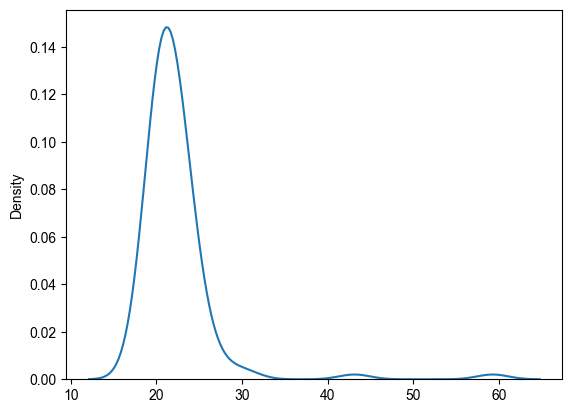

In [43]:
sns.kdeplot(cvs, clip = (0,200))

In [44]:
np.mean(cvs)

22.246121288299463

In [45]:
CoV_ByWell = pd.DataFrame({'WELL' : wu, 'COV' : cvs})

In [46]:
CoV_ByWell.query('22 < COV < 23')

,WELL,COV
36,251027_H04,22.948000
38,251027_K14,22.530375
44,251027_J04,22.178313
45,251027_H09,22.675544
46,251027_I10,22.720695
51,251027_K17,22.080388
57,251027_E09,22.931722
65,251027_K20,22.443956
66,251027_G05,22.959677
78,251027_E19,22.568684


In [47]:
ExcludedWells = CoV_ByWell.query('COV > 35').WELL.tolist()
PolII_Variation = PolII_Variation.query('WELL_UNIQUE not in @ExcludedWells')

<Axes: >

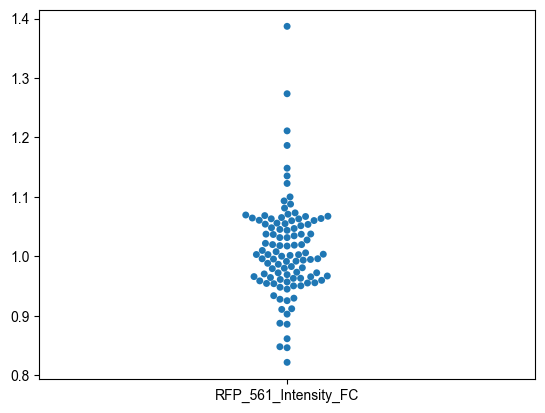

In [48]:
RFP_Mean = PolII_Variation[['WELL_UNIQUE', 'RFP_561_Intensity_FC']].groupby('WELL_UNIQUE').mean().reset_index()
sns.swarmplot(RFP_Mean)

In [49]:
ExcludedWells2 = RFP_Mean.query('RFP_561_Intensity_FC > 1.2')['WELL_UNIQUE'].tolist()
PolII_Variation = PolII_Variation.query('WELL_UNIQUE not in @ExcludedWells2')

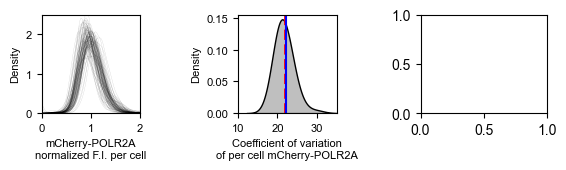

In [50]:
f, a = plt.subplots(figsize = (6,1.8), ncols = 3)

for i in PolII_Variation.WELL_UNIQUE.unique():
    sns.kdeplot(PolII_Variation.query('WELL_UNIQUE == @i'),
                x = 'RFP_561_Intensity_FC',
                fill = False,
                color = 'black', alpha = 0.2, linewidth = 0.2,
                clip = (0,2),
                ax = a[0])

a[0].set_box_aspect(1)
a[0].set_xlim(0,2)
a[0].set_ylim(0,2.5)
a[0].set_ylabel('Density', fontsize = 8)
a[0].set_xlabel('mCherry-POLR2A\nnormalized F.I. per cell', fontsize = 8)

a[0].tick_params(axis = 'both', labelsize = 8)


sns.kdeplot(CoV_ByWell,
            x = 'COV',
            color = 'black',
            fill = True,
            clip = (10,35),
            ax = a[1])

a[1].axvline(22.04, color = 'red', linestyle = '--', linewidth = 2)
a[1].axvline(22.25, color = 'blue')

a[1].set_box_aspect(1)
a[1].set_xlim(10,35)
#a[1].set_ylim(0,2.5)
a[1].set_ylabel('Density', fontsize = 8)
a[1].set_xlabel('Coefficient of variation\nof per cell mCherry-POLR2A', fontsize = 8)
a[1].tick_params(axis = 'both', labelsize = 8)

plt.tight_layout()

plt.savefig('mcherry_variance_perwell_cov.svg')

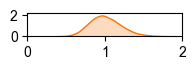

In [51]:
f, a = plt.subplots(figsize = (2,1.8))

sns.kdeplot(PolII_Variation,
            x = 'RFP_561_Intensity_FC',
            color = 'xkcd:orange',
            fill = True,
            clip = (0,2),
            ax = a)

a.set_box_aspect(0.15)
a.set_ylabel('')
a.set_xlabel('')
a.set_ylim(0,2.2)
a.set_xlim(0,2)

plt.savefig('mch_polr2a_total_polII_vehicle_allcells.svg')

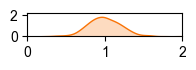

In [52]:
f, a = plt.subplots(figsize = (2,1.8))

sns.kdeplot(IntensitiesByCell.query('WELL_UNIQUE == "251027_J04"'),
            x = 'RFP_561_Intensity_FC',
            color = 'xkcd:orange',
            fill = True,
            clip = (0,2),
            ax = a)

a.set_box_aspect(0.15)
a.set_ylabel('')
a.set_xlabel('')
a.set_ylim(0,2.2)
a.set_xlim(0,2)

plt.savefig('mch_polr2a_total_polII_vehicle_singlewell.svg')

## check densities

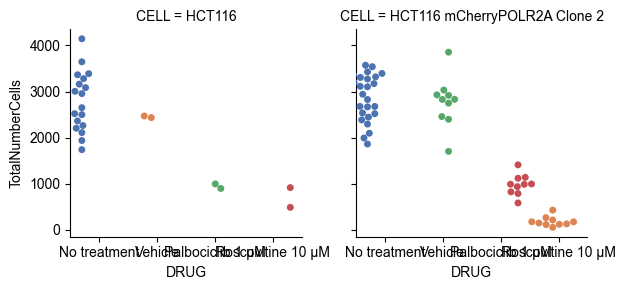

In [53]:
g = sns.FacetGrid(Experiment1_IntensitiesByWell,
                  col = 'CELL')

g.map_dataframe(sns.swarmplot,
                x = 'DRUG',
                y = 'TotalNumberCells',
                hue = 'DRUG', dodge = True,
                palette = 'deep')

g.add_legend()

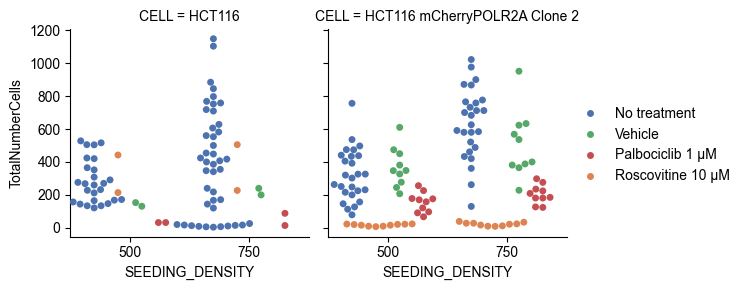

In [54]:
g = sns.FacetGrid(Experiment2_IntensitiesByWell,
                  col = 'CELL')

g.map_dataframe(sns.swarmplot,
                x = 'SEEDING_DENSITY',
                y = 'TotalNumberCells',
                hue = 'DRUG', dodge = True,
                palette = 'deep')

g.add_legend()
              

In [55]:
Experiment1_IntensitiesByWell['EXPERIMENT'] = '251020'
Experiment2_IntensitiesByWell['EXPERIMENT'] = '251027'

In [56]:
IntensitiesByWell = pd.concat([Experiment1_IntensitiesByWell, Experiment2_IntensitiesByWell])

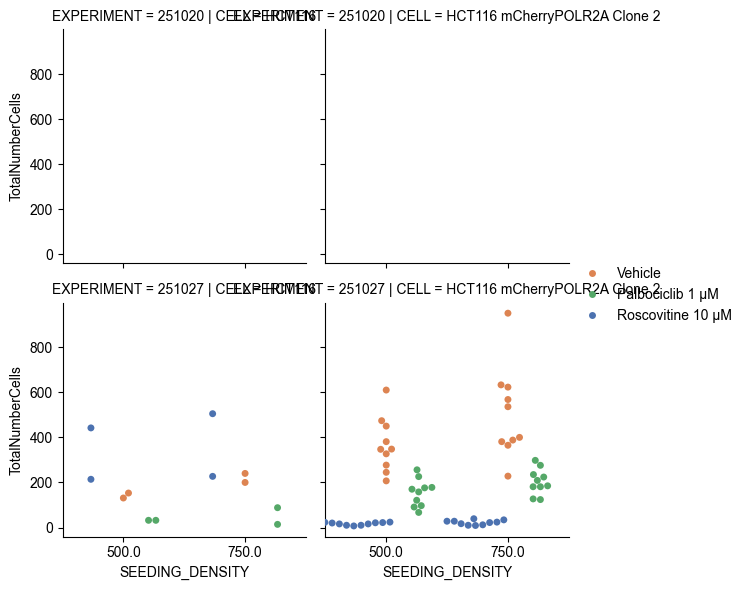

In [57]:
g = sns.FacetGrid(IntensitiesByWell.query('DRUG != "No treatment"'),
                  col = 'CELL', row = 'EXPERIMENT')

g.map_dataframe(sns.swarmplot,
                x = 'SEEDING_DENSITY',
                y = 'TotalNumberCells',
                hue = 'DRUG', dodge = True,
                palette = 'deep')

g.add_legend()
              